In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.listdir()

['.config', 'drive', 'sample_data']

In [ ]:
os.listdir('/content/drive/MyDrive')

['Sunflower Wallpaper Set',
 'Untitled spreadsheet.gsheet',
 'Untitled document.gdoc',
 'Colab Notebooks',
 'PythonAnalisis']

In [ ]:
#Load Dataset
orders = pd.read_csv("/content/drive/MyDrive/PythonAnalisis/Olist_Project/Dataset/olist_orders_dataset.csv")
products = pd.read_csv("/content/drive/MyDrive/PythonAnalisis/Olist_Project/Dataset/olist_products_dataset.csv")
reviews = pd.read_csv("/content/drive/MyDrive/PythonAnalisis/Olist_Project/Dataset/olist_order_reviews_dataset.csv")
sellers = pd.read_csv("/content/drive/MyDrive/PythonAnalisis/Olist_Project/Dataset/olist_sellers_dataset.csv")
category = pd.read_csv("/content/drive/MyDrive/PythonAnalisis/Olist_Project/Dataset/product_category_name_translation.csv")
order_items = pd.read_csv("/content/drive/MyDrive/PythonAnalisis/Olist_Project/Dataset/olist_order_items_dataset.csv")
geolocation = pd.read_csv("/content/drive/MyDrive/PythonAnalisis/Olist_Project/Dataset/olist_geolocation_dataset.csv")
payments = pd.read_csv("/content/drive/MyDrive/PythonAnalisis/Olist_Project/Dataset/olist_order_payments_dataset.csv")
customers = pd.read_csv("/content/drive/MyDrive/PythonAnalisis/Olist_Project/Dataset/olist_customers_dataset.csv")

In [ ]:
#Cek jumlah baris dan kolom di masin-masing dataset
dataset = {
    "orders": orders,
    "products": products,
    "reviews" : reviews,
    "sellers" : sellers,
    "category" : category,
    "order_items" : order_items,
    "geolocation" : geolocation,
    "payments" : payments,
    "customers" : customers
}

for nama, df in dataset.items():
  print(f"{nama}: {df.shape}")

orders: (99441, 8)
products: (32951, 9)
reviews: (99224, 7)
sellers: (3095, 4)
category: (71, 2)
order_items: (112650, 7)
geolocation: (1000163, 5)
payments: (103886, 5)
customers: (99441, 5)


In [ ]:
#cek data yang duplikat
for nama, df in dataset.items():
  print(f"{nama}:", df.duplicated().sum())


orders: 0
products: 0
reviews: 0
sellers: 0
category: 0
order_items: 0
geolocation: 261831
payments: 0
customers: 0


In [ ]:
#cek data kosong
for nama, df in dataset.items():
  print(f"\n{'='*50}")
  print(nama.upper())
  print(df.isnull().sum())


ORDERS
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

PRODUCTS
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

REVIEWS
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

SELLERS
seller_id                 0
seller_zip_code_prefix    0
seller_city               0


Explore Dataset

In [ ]:
#1. Apa saja status order
orders["order_status"].value_counts()

,count
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


In [ ]:
#2. Review pelanggan
reviews["review_score"].value_counts().sort_index()

,count
review_score,
1,11424
2,3151
3,8179
4,19142
5,57328


In [ ]:
#3. Tipe Pembayaran
payments['payment_type'].value_counts()

,count
payment_type,
credit_card,76795
boleto,19784
voucher,5775
debit_card,1529
not_defined,3


In [ ]:
#4. Wilayah Customer
customers['customer_state'].value_counts()

,count
customer_state,
SP,41746
RJ,12852
MG,11635
RS,5466
PR,5045
SC,3637
BA,3380
DF,2140
ES,2033


In [ ]:
#5. Persentase review score
reviews['review_score'].value_counts(normalize=True).sort_index() * 100

,proportion
review_score,
1,11.513344
2,3.175643
3,8.242965
4,19.291704
5,57.776344


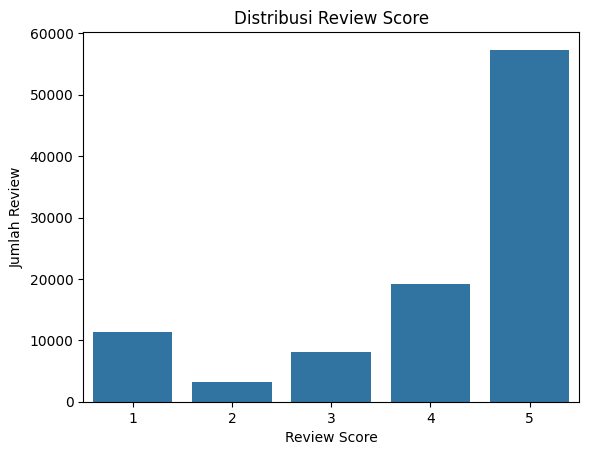

In [ ]:
#6. Distribusi review score
sns.countplot(
    data=reviews,
    x='review_score'
)
plt.title('Distribusi Review Score')
plt.xlabel('Review Score')
plt.ylabel('Jumlah Review')
plt.show()

review score 1 lebih tinggi dari rating 2 dan 3, meskipun rating 4 dan 5 tinggi, namun indikasi rating 1 perlu dianalisis lebih lanjut untuk menemukan faktor yang berkaitan dengan rating 1 yang tinggi tersebut

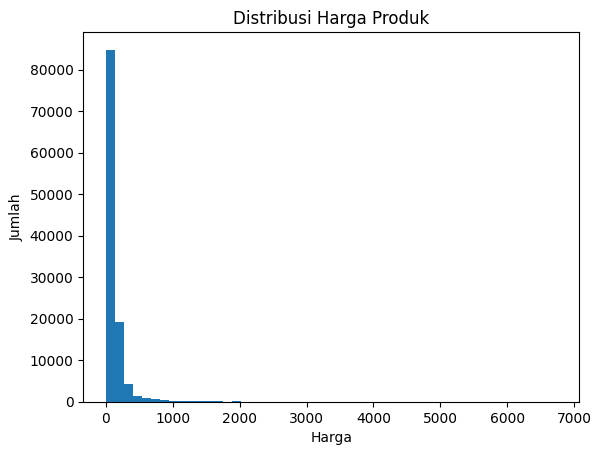

In [ ]:
#7. Distribusi Harga Produk
plt.hist(order_items['price'], bins=50)
plt.title('Distribusi Harga Produk')
plt.xlabel('Harga')
plt.ylabel('Jumlah')
plt.show()

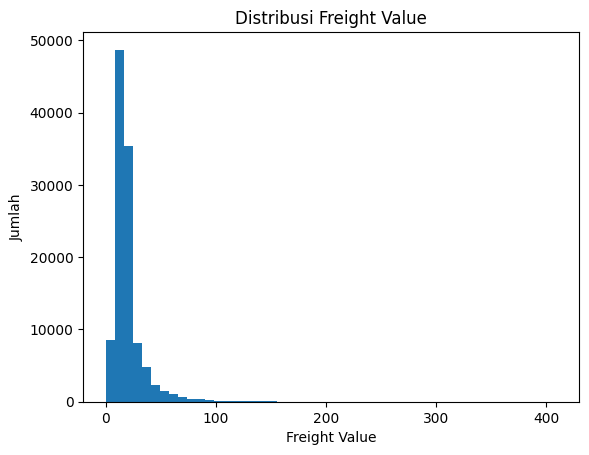

In [ ]:
#8. Distribusi Biaya Ongkir
plt.hist(order_items['freight_value'], bins=50)
plt.title("Distribusi Freight Value")
plt.xlabel('Freight Value')
plt.ylabel('Jumlah')
plt.show()

**CLEANING DATASET**

In [ ]:
#Buat Dataset baru dengan tabel dan kolom yang digunakan analisis
#Olist orders dataset
orders_analysis = orders[
    ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
     'order_delivered_customer_date', 'order_estimated_delivery_date']
].copy()

#olist reviews dataset
review_analysis = reviews[
    ['order_id', 'review_score', 'review_creation_date']
].copy()

#olist customers dataset
customers_analysis = customers[
    ['customer_id', 'customer_unique_id', 'customer_state']
].copy()

#olist order items
order_items_analysis = order_items[
    ['order_id', 'order_item_id', 'product_id', 'seller_id', 'price', 'freight_value']
].copy()

#olist product dataset
product_analysis = products[
    ['product_id', 'product_category_name']
].copy()

#olist seller dataset
seller_analysis = sellers[
    ['seller_id', 'seller_state']
]

#category translation
category_analysis = category[
    ['product_category_name', 'product_category_name_english']
].copy()

In [ ]:
review_analysis['review_creation_date'] = pd.to_datetime(review_analysis['review_creation_date'])

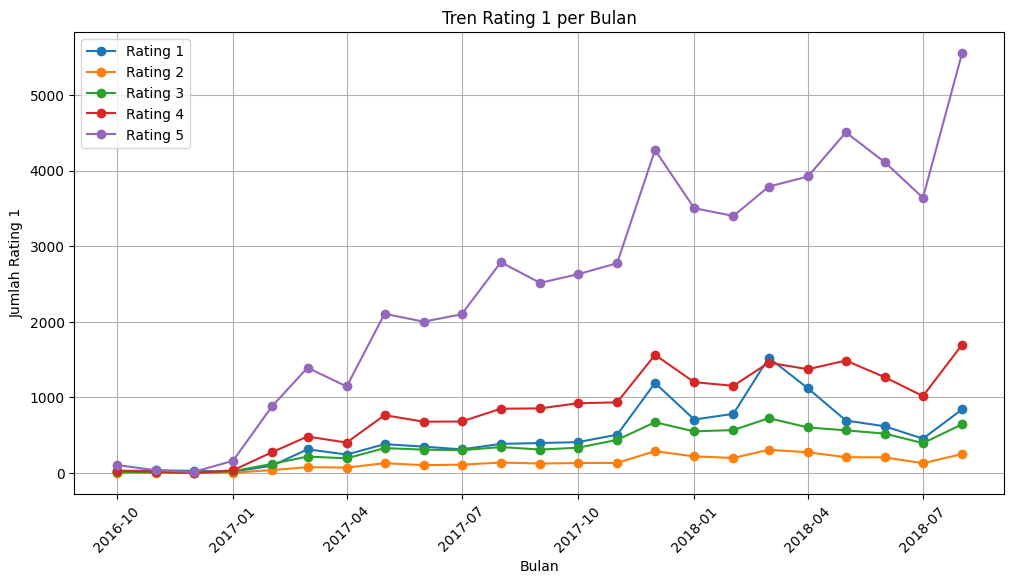

In [ ]:
rating1_bulanan = (review_analysis.set_index('review_creation_date').groupby(pd.Grouper(freq='MS'))['review_score']
    .value_counts()
    .unstack(fill_value=0))

plt.figure(figsize=(12, 6))
for rating in [1, 2, 3, 4, 5]:
  plt.plot(rating1_bulanan.index, rating1_bulanan[rating], marker='o', label=f'Rating {rating}')
plt.title('Tren Rating 1 per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Rating 1')

plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.show()

Rating 1 menduduki peringkat ke 3 sebagai rating dengan jumlah data order pelanggan terbanyak, dibanding rating 2 dan 3, meskipun rating 4 dan 5 masih mendominasi, namun rating 1 perlu dianalisis lebih lanjut

In [ ]:
#informasi jumlah baris dan kosong di masing-masing tabel diatas
dataset_analysis = {
    'reviews': review_analysis,
    'orders' : orders_analysis,
    'customers' : customers_analysis,
    'order_items' : order_items_analysis,
    'product' : product_analysis,
    'sellers' : seller_analysis,
    'category' : category_analysis
}

for nama, df in dataset_analysis.items():
  print(nama.upper())
  print('=' * 50)
  print(df.shape)
  print(df.columns.tolist())
  print()

REVIEWS
(99224, 3)
['order_id', 'review_score', 'review_creation_date']

ORDERS
(99441, 6)
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date']

CUSTOMERS
(99441, 3)
['customer_id', 'customer_unique_id', 'customer_state']

ORDER_ITEMS
(112650, 6)
['order_id', 'order_item_id', 'product_id', 'seller_id', 'price', 'freight_value']

PRODUCT
(32951, 2)
['product_id', 'product_category_name']

SELLERS
(3095, 2)
['seller_id', 'seller_state']

CATEGORY
(71, 2)
['product_category_name', 'product_category_name_english']



In [ ]:
#infromasi baris kosong di masing-masing tabel
for nama, df in dataset_analysis.items():
  print(nama.upper())
  print(df.isnull().sum())
  print()

REVIEWS
order_id                0
review_score            0
review_creation_date    0
dtype: int64

ORDERS
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

CUSTOMERS
customer_id           0
customer_unique_id    0
customer_state        0
dtype: int64

ORDER_ITEMS
order_id         0
order_item_id    0
product_id       0
seller_id        0
price            0
freight_value    0
dtype: int64

PRODUCT
product_id                 0
product_category_name    610
dtype: int64

SELLERS
seller_id       0
seller_state    0
dtype: int64

CATEGORY
product_category_name            0
product_category_name_english    0
dtype: int64



In [ ]:
#cek duplikat
for nama, df in dataset_analysis.items():
  print(f'{nama}:', df.duplicated().sum())

reviews: 126
orders: 0
customers: 0
order_items: 0
product: 0
sellers: 0
category: 0


In [ ]:
#cari tahu kolom kosong di tabel orders
orders_analysis.loc[
    orders_analysis["order_delivered_customer_date"].isnull(), #kondisi
    ["order_delivered_customer_date", "order_status"] #kolom yg mau ditampilkan
]

,order_delivered_customer_date,order_status
6,NaN,invoiced
44,NaN,shipped
103,NaN,invoiced
128,NaN,processing
154,NaN,shipped
...,...,...
99283,NaN,canceled
99313,NaN,processing
99347,NaN,canceled
99348,NaN,unavailable


In [ ]:
#lihat sebaran data yang kosong di order delivered statusnya apa saja
orders_analysis.loc[
    orders_analysis['order_delivered_customer_date'].isnull(),
    'order_status'
].value_counts()

,count
order_status,
shipped,1107
canceled,619
unavailable,609
invoiced,314
processing,301
delivered,8
created,5
approved,2


In [ ]:
#ambil baris data kosong tersebut yang statusnya delivered
delivered_kosong = orders_analysis[
    (orders_analysis['order_status'] == 'delivered') & (orders_analysis['order_delivered_customer_date'].isnull())
]
delivered_kosong

,order_id,customer_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date
3002,2d1e2d5bf4dc7227b3bfebb81328c15f,ec05a6d8558c6455f0cbbd8a420ad34f,delivered,2017-11-28 17:44:07,NaN,2017-12-18 00:00:00
20618,f5dd62b788049ad9fc0526e3ad11a097,5e89028e024b381dc84a13a3570decb4,delivered,2018-06-20 06:58:43,NaN,2018-07-16 00:00:00
43834,2ebdfc4f15f23b91474edf87475f108e,29f0540231702fda0cfdee0a310f11aa,delivered,2018-07-01 17:05:11,NaN,2018-07-30 00:00:00
79263,e69f75a717d64fc5ecdfae42b2e8e086,cfda40ca8dd0a5d486a9635b611b398a,delivered,2018-07-01 22:05:55,NaN,2018-07-30 00:00:00
82868,0d3268bad9b086af767785e3f0fc0133,4f1d63d35fb7c8999853b2699f5c7649,delivered,2018-07-01 21:14:02,NaN,2018-07-24 00:00:00
92643,2d858f451373b04fb5c984a1cc2defaf,e08caf668d499a6d643dafd7c5cc498a,delivered,2017-05-25 23:22:43,NaN,2017-06-23 00:00:00
97647,ab7c89dc1bf4a1ead9d6ec1ec8968a84,dd1b84a7286eb4524d52af4256c0ba24,delivered,2018-06-08 12:09:39,NaN,2018-06-26 00:00:00
98038,20edc82cf5400ce95e1afacc25798b31,28c37425f1127d887d7337f284080a0f,delivered,2018-06-27 16:09:12,NaN,2018-07-19 00:00:00


In [ ]:
#melihat apakah 8 baris kosong ini ada ratingnya, jika iya jangan dihapus 8 baris ini karena memuat informasi penting rating
delivered_kosong_rating = delivered_kosong.merge(
    review_analysis, on='order_id', how='left'
)
delivered_kosong_rating

,order_id,customer_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,review_score,review_creation_date
0,2d1e2d5bf4dc7227b3bfebb81328c15f,ec05a6d8558c6455f0cbbd8a420ad34f,delivered,2017-11-28 17:44:07,NaN,2017-12-18 00:00:00,5,2017-12-19
1,f5dd62b788049ad9fc0526e3ad11a097,5e89028e024b381dc84a13a3570decb4,delivered,2018-06-20 06:58:43,NaN,2018-07-16 00:00:00,5,2018-06-29
2,2ebdfc4f15f23b91474edf87475f108e,29f0540231702fda0cfdee0a310f11aa,delivered,2018-07-01 17:05:11,NaN,2018-07-30 00:00:00,5,2018-07-11
3,e69f75a717d64fc5ecdfae42b2e8e086,cfda40ca8dd0a5d486a9635b611b398a,delivered,2018-07-01 22:05:55,NaN,2018-07-30 00:00:00,5,2018-07-07
4,0d3268bad9b086af767785e3f0fc0133,4f1d63d35fb7c8999853b2699f5c7649,delivered,2018-07-01 21:14:02,NaN,2018-07-24 00:00:00,5,2018-07-06
5,2d858f451373b04fb5c984a1cc2defaf,e08caf668d499a6d643dafd7c5cc498a,delivered,2017-05-25 23:22:43,NaN,2017-06-23 00:00:00,5,2017-06-25
6,ab7c89dc1bf4a1ead9d6ec1ec8968a84,dd1b84a7286eb4524d52af4256c0ba24,delivered,2018-06-08 12:09:39,NaN,2018-06-26 00:00:00,1,2018-06-16
7,20edc82cf5400ce95e1afacc25798b31,28c37425f1127d887d7337f284080a0f,delivered,2018-06-27 16:09:12,NaN,2018-07-19 00:00:00,5,2018-07-06


data 8 kosong ini dipertahankan karena akan digunakan untuk analisis rating meskipun tanggalnya tidak ada, tapi tidak diisi tanggal review karena belum pasti tanggal tersebut adalah tanggal barang sampai

In [ ]:
#Ada berapa order_id yang muncul lebih dari satu kali?
review_analysis["order_id"].value_counts().gt(1).sum()

np.int64(547)

In [ ]:
#berapa kali muncul
review_analysis["order_id"].value_counts().value_counts().sort_index()

,count
count,
1,98126
2,543
3,4


In [ ]:
review_analysis.groupby("order_id")["review_score"].nunique().value_counts()

,count
review_score,
1,98471
2,202


In [ ]:
#menemukan order yang ratingnya berbeda
rating_berbeda = (
    review_analysis
    .groupby("order_id")["review_score"]
    .nunique()
)

rating_berbeda[rating_berbeda > 1]

,review_score
order_id,
013056cfe49763c6f66bda03396c5ee3,2
02355020fd0a40a0d56df9f6ff060413,2
029863af4b968de1e5d6a82782e662f5,2
03c939fd7fd3b38f8485a0f95798f1f6,2
03eba6d9fef8f5b3e811d4b5a7cca9cd,2
...,...
fa350da9efbba83c2957b629bf6c2c7c,2
fc3d87913825143fa41c48e40267c47a,2
fcde2f7449493b4f207a23fae117b0fb,2


In [ ]:
#melakukan cleaning terhadap 547 baris data duplikat di tabel review
#ubah tipe data tanggal ke datetime
review_analysis['review_creation_date'] = pd.to_datetime(review_analysis['review_creation_date'])

#urutkan order berdasarkan tanggal
review_analysis = review_analysis.sort_values('review_creation_date')

review_analysis.head()

,order_id,review_score,review_creation_date
70906,809a282bbd5dbcabb6f2f724fca862ec,1,2016-10-02
37547,bfbd0f9bdef84302105ad712db648a6c,1,2016-10-06
5503,e5215415bb6f76fe3b7cb68103a0d1c0,1,2016-10-09
60439,e2144124f98f3bf46939bc5183104041,4,2016-10-15
41042,9aa3197e4887919fde0307fc23601d7a,4,2016-10-15


In [ ]:
#ambil data record pertama order_id berdasarkan tanggal yang telah diurutkan
review_analysis = review_analysis.drop_duplicates(
    subset='order_id',
    keep='first'
)

In [ ]:
#cek duplikat tabel reviews kembali
review_analysis['order_id'].duplicated().sum()

np.int64(0)

In [ ]:
#atasi 610 baris category name yang kosong di tabel product analysis
#tambahkan kolom translate bahasa category ke tabel product_analysis dari tabel translate category
product_analysis = product_analysis.merge(
    category_analysis,
    on='product_category_name',
    how='left'
)

product_analysis.head(20)


,product_id,product_category_name,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,housewares
5,41d3672d4792049fa1779bb35283ed13,instrumentos_musicais,musical_instruments
6,732bd381ad09e530fe0a5f457d81becb,cool_stuff,cool_stuff
7,2548af3e6e77a690cf3eb6368e9ab61e,moveis_decoracao,furniture_decor
8,37cc742be07708b53a98702e77a21a02,eletrodomesticos,home_appliances
9,8c92109888e8cdf9d66dc7e463025574,brinquedos,toys


In [ ]:
product_analysis.isnull().sum()

,0
product_id,0
product_category_name,610
product_category_name_english,623


In [ ]:
#Dari products_analysis, ambil produk yang kategori englishnya kosong, lalu ambil product_category_name, kemudian hitung kemunculannya.
product_analysis[
    product_analysis['product_category_name_english'].isnull()
]['product_category_name'].value_counts(dropna=False)

,count
product_category_name,
NaN,610
portateis_cozinha_e_preparadores_de_alimentos,10
pc_gamer,3


In [ ]:
#isi baris kosong di category name dengan nama kategori Unknown
product_analysis['product_category_name'] = product_analysis['product_category_name'].fillna('Unknown')
product_analysis['product_category_name_english'] = product_analysis['product_category_name_english'].fillna('Unknown')

In [ ]:
product_analysis.isnull().sum()

,0
product_id,0
product_category_name,0
product_category_name_english,0


EDA untuk analisis rating 1 itu sebenarnya berkaitan dengan apa?

In [ ]:
orders_analysis['order_purchase_timestamp'] = pd.to_datetime(orders_analysis['order_purchase_timestamp'])
orders_analysis['order_delivered_customer_date'] = pd.to_datetime(orders_analysis['order_delivered_customer_date'])
orders_analysis['order_estimated_delivery_date'] = pd.to_datetime(orders_analysis['order_estimated_delivery_date'])

In [ ]:
#1. Apakah lama pengiriman berkaitan dengan rating pelanggan?

#buat tabel order yang isinya status order delivered supaya menghitung rating yang berkaitan dengan pesanan yang memang sudah sampai atau delivered
orders_delivered = orders_analysis[orders_analysis['order_status'] == 'delivered'].copy()

#gabung dengan tabel reviews untuk melihat data yang statusnya delivered dan ada rating
analysis_1 = orders_delivered.merge(
    review_analysis, on='order_id', how='inner'
)

#hitung lama pengiriman
analysis_1['durasi_pengiriman'] = (
    analysis_1['order_delivered_customer_date'] - analysis_1['order_purchase_timestamp']
).dt.days


In [ ]:
#persentase durasi pengiriman dengan rating
analysis_1_delivery = analysis_1[analysis_1["durasi_pengiriman"].notna()].copy()
rating_pengiriman = analysis_1_delivery.groupby("review_score")["durasi_pengiriman"].mean().round(0)
rating_pengiriman

,durasi_pengiriman
review_score,
1,21.0
2,16.0
3,14.0
4,12.0
5,10.0


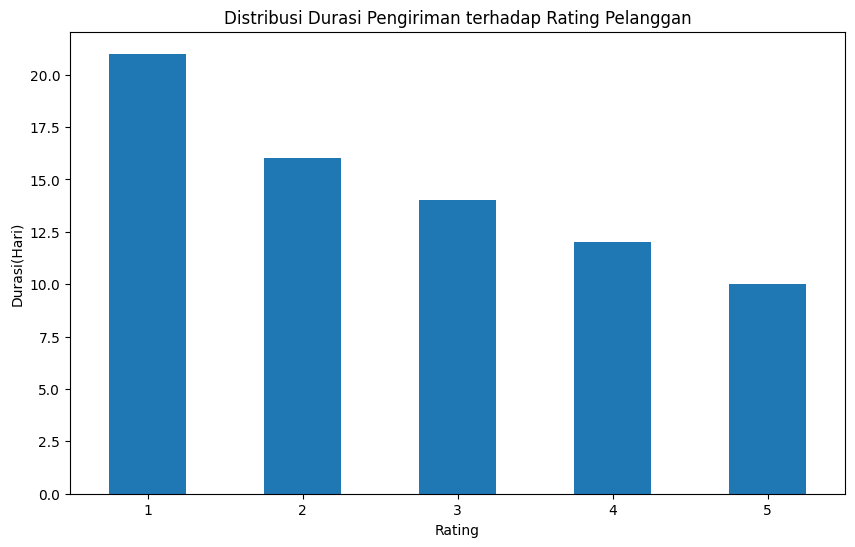

In [ ]:
rating_pengiriman.plot(
    kind='bar',
    figsize=(10, 6)
)
plt.title('Distribusi Durasi Pengiriman terhadap Rating Pelanggan')
plt.ylabel('Durasi(Hari)')
plt.xlabel('Rating')
plt.xticks(rotation=0)
plt.show()

Grafik batang tersebut menunjukkan bahwa terdapat hubungan rating rendah dengan durasi pengiriman yang dibuktikan dengan rating 1 yang menempati durasi terlama dengan rating 5 menunjukkan durasi tercepat. Hal ini mengindikasikan bahwa beberapa pelanggan yang memberikan rating 1 itu berkorelasi dengan durasi pengiriman yang lama.

In [ ]:
#2. Bagaimana dengan pesanan yang terlambat datang dari estimasi, apakah berkorelasi dengan rating rendah?
analysis_1['terlambat(hari)'] = (analysis_1['order_delivered_customer_date'] - analysis_1['order_estimated_delivery_date']).dt.days

#buat status order apakah terlambat, tepat waktu, atau lebih cepat
analysis_1['status_keterlambatan'] = analysis_1['terlambat(hari)'].apply(
    lambda x: 'Unknown' if pd.isna(x)
    else 'Lebih Awal' if x < 0
    else 'Tepat Waktu' if x == 0
    else 'Terlambat'
)

#tampilkan jumlah data di masing-masing status keterlambatan
analysis_1['status_keterlambatan'].value_counts()

,count
status_keterlambatan,
Lebih Awal,88163
Terlambat,6381
Tepat Waktu,1280
Unknown,8


ada sekitar 6000+ order yang terlambat dari estimasi yang telah ditentukan.
mari kita lihat bagaimana performa rating dari pesanan yang terlambat dari estimasi.

In [ ]:
#persentase rating 1-5
rating_status = pd.crosstab(
    analysis_1["status_keterlambatan"],
    analysis_1["review_score"],
    normalize="index"
) * 100
rating_status = rating_status.drop(index='Unknown')
rating_status.style.format('{:.1f}%')

review_score,1,2,3,4,5
status_keterlambatan,,,,,
Lebih Awal,6.6%,2.6%,8.0%,20.4%,62.5%
Tepat Waktu,8.4%,3.9%,13.8%,23.3%,50.6%
Terlambat,53.7%,8.7%,10.8%,10.2%,16.6%


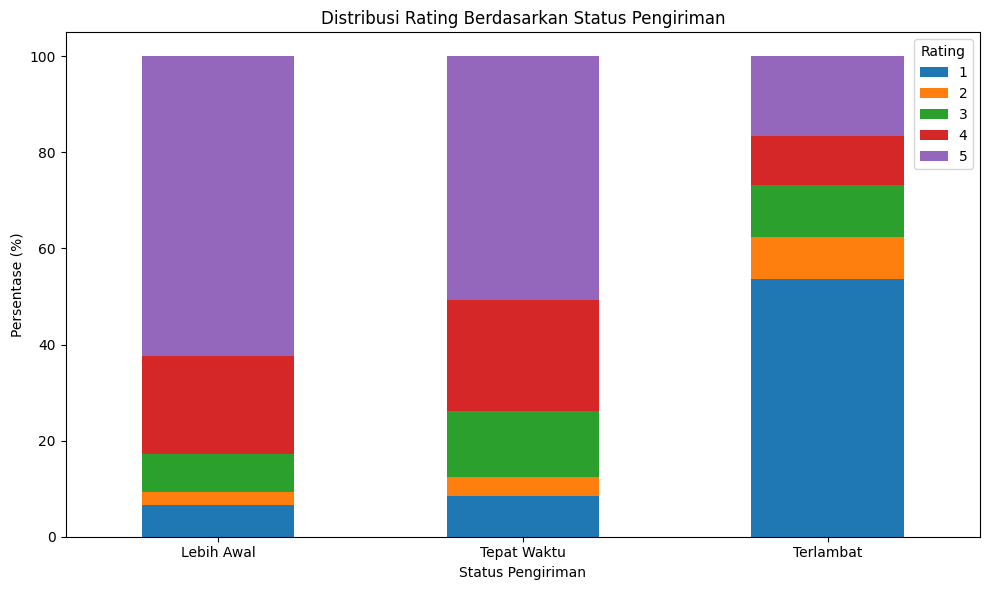

In [ ]:
rating_status.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)
plt.title('Distribusi Rating Berdasarkan Status Pengiriman')
plt.xlabel("Status Pengiriman")
plt.ylabel("Persentase (%)")
plt.xticks(rotation=0)
plt.legend(title="Rating")
plt.tight_layout()

plt.show()

fokus pada performa batang status pengiriman yang terlambat, Hasilnya memperlihatkan bahwa persentase barang yang terlambat dari estimasi memiliki rating 1 yang cukup tinggi (53.7%), seperdua dari rating 2-5, hal ini menunjukkan hubungan yang kuat antara barang yang terlambat dari estimasi dengan pemberian rating rendah dari pelanggan.

In [ ]:
#selanjutnya kita ingin melihat apakah biaya ongkir berpengaruh terhadap rendahnya rating pelanggan
#menggabungkan tabel
analysis_2 = analysis_1.merge(order_items_analysis[['order_id', 'freight_value']],
            on='order_id', how='left')
analysis_2[['order_id', 'review_score', 'freight_value']].head()

#rating rata-rata ongkir per review score/rating
rating_ongkir = analysis_2.groupby('review_score')['freight_value'].mean().round(2)
rating_ongkir

,freight_value
review_score,
1,21.09
2,20.94
3,20.30
4,20.05
5,19.57


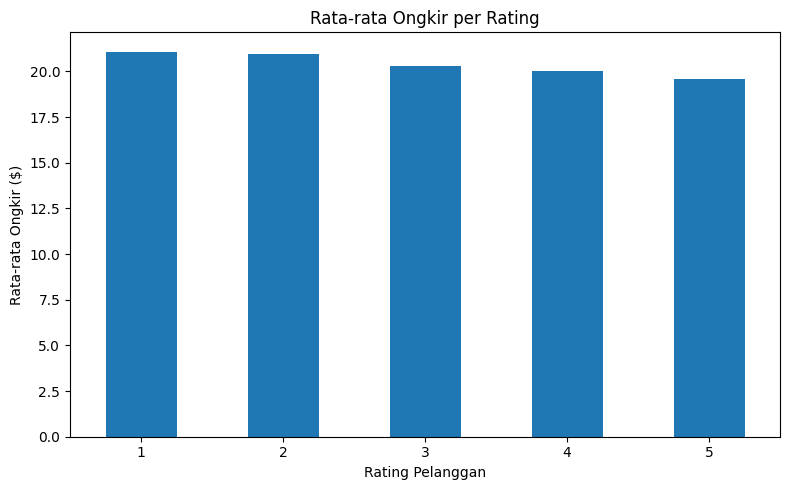

In [ ]:
rating_ongkir.plot(kind='bar', figsize=(8,5))
plt.title('Rata-rata Ongkir per Rating')
plt.xlabel('Rating Pelanggan')
plt.ylabel('Rata-rata Ongkir ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Rata-rata ongkir dengan rating pelanggan menunjukkan hasil yang hampir seragam antar rating, hal ini mengindikasikan hubungan biaya ongkir dan rating pelanggan tidak menunjukkan pengaruh yang signifikan terhadap penilaian pelanggan.

In [ ]:
#kalau dari harga produk apakah berpengaruh terhadap rating?
analysis_3 = analysis_2.merge(
    order_items_analysis[['order_id', 'price']],
    on='order_id', how='left'
)

rating_harga = analysis_3.groupby('review_score')['price'].mean().round(2)
rating_harga

,price
review_score,
1,108.18
2,102.01
3,101.36
4,109.47
5,110.88


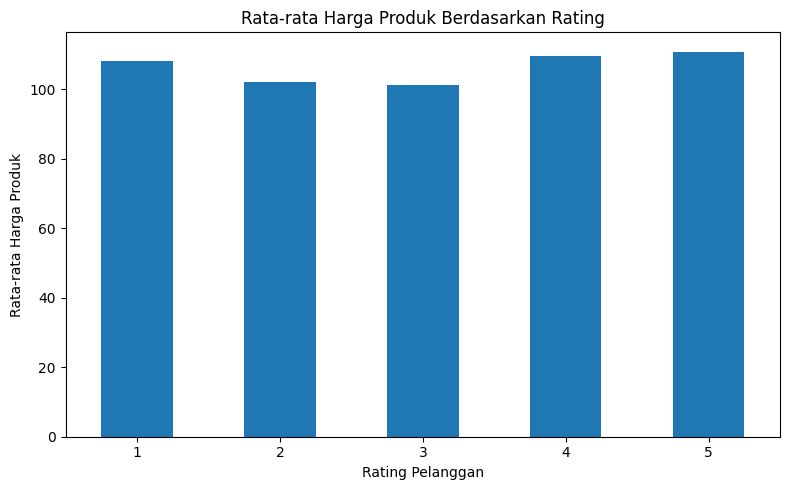

In [ ]:
rating_harga.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Rata-rata Harga Produk Berdasarkan Rating")
plt.xlabel("Rating Pelanggan")
plt.ylabel("Rata-rata Harga Produk")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

rata-rata harga barang yang tersebar di beberapa rating hampir seragam, hanya selisih sedikit antar rating, jadi berdasarkan output diatas, harga tidak menunjukkan pengaruh signifikan terhadap pemberian rating rendah oleh pelanggan.

In [ ]:
#Bagaimana dengan perbedaan rute/state antara seller dan customer yang mengalami keterlambatan paling parah dan mendapatkan rating 1
#Karena sebelumnya kita menemukan bahwa rating 1 berhubungan dengan keterlambatan barang sampai ke pelanggan, jadi kita ingin mengidentifikasi rute mana antara seller ke customer yang memiliki rating 1 dengan keterlambatan paling parah.
#buat tabel analisis rating 1 dari analysis_1
analysis_state_rating1 = analysis_1[analysis_1['review_score'] == 1].copy()

#buat tabel penghubung
order_seller = (order_items[['order_id', 'seller_id']].drop_duplicates())

#masukkan seller id ke analisis state rating 1
analysis_state_rating1 = analysis_state_rating1.merge(order_seller, on='order_id', how='left')

#tambahkan seller state
analysis_state_rating1 =  analysis_state_rating1.merge(
    sellers[['seller_id', 'seller_state']], on='seller_id', how='left')

#Tambahkan customer_state
analysis_state_rating1 = analysis_state_rating1.merge(
    customers[['customer_id', 'customer_state']], on='customer_id', how='left')

analysis_state_rating1.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,review_score,review_creation_date,durasi_pengiriman,terlambat(hari),status_keterlambatan,seller_id,seller_state,customer_state
0,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-02-02 14:08:10,2017-03-06,1,2017-02-03,9.0,-32.0,Lebih Awal,63b9ae557efed31d1f7687917d248a8d,SP,RS
1,e6ce16cb79ec1d90b1da9085a6118aeb,494dded5b201313c64ed7f100595b95c,delivered,2017-05-16 19:41:10,2017-05-29 11:18:31,2017-06-07,1,2017-05-30,12.0,-9.0,Lebih Awal,001cca7ae9ae17fb1caed9dfb1094831,ES,RJ
2,acce194856392f074dbf9dada14d8d82,7e20bf5ca92da68200643bda76c504c6,delivered,2018-06-04 00:00:13,2018-06-16 15:20:55,2018-07-18,1,2018-06-17,12.0,-32.0,Lebih Awal,977f9f63dd360c2a32ece2f93ad6d306,SP,BA
3,acce194856392f074dbf9dada14d8d82,7e20bf5ca92da68200643bda76c504c6,delivered,2018-06-04 00:00:13,2018-06-16 15:20:55,2018-07-18,1,2018-06-17,12.0,-32.0,Lebih Awal,d673a59aac7a70d8b01e6902bf090a11,SP,BA
4,1790eea0b567cf50911c057cf20f90f9,52142aa69d8d0e1247ab0cada0f76023,delivered,2018-04-16 21:15:39,2018-05-05 12:28:34,2018-05-15,1,2018-05-06,18.0,-10.0,Lebih Awal,d91fb3b7d041e83b64a00a3edfb37e4f,SP,PE


In [ ]:
#Pada pesanan rating 1 yang memang terlambat, rute seller → customer mana yang paling banyak mengalami kasus tersebut, dan seberapa parah keterlambatannya?
rating1_rute = analysis_state_rating1[analysis_state_rating1['terlambat(hari)'] > 0].copy()


analisis_rating1_rute = (rating1_rute.groupby(['seller_state', 'customer_state'])
                                  .agg(jumlah_rating1 = ('review_score', 'count'),
                                    ratarata_terlambat=('terlambat(hari)', 'mean')).round(2)
                                    .sort_values('jumlah_rating1', ascending=False))

analisis_rating1_rute.head(20)

jumlah_rating1  ratarata_terlambat
seller_state customer_state                                    
SP           RJ                         739               14.98
             SP                         621                9.47
             MG                         203                9.17
             BA                         148               10.10
             RS                         126               10.70
             SC                         106                9.48
PR           RJ                          81               16.52
SP           ES                          80               10.11
             CE                          71               17.82
             PE                          69               13.46
             PR                          63               10.13
RJ           SP                          59               11.00
PR           SP                          58               13.00
SP           DF                          57                8.33
             GO                          52               12.48
MG           RJ                          52               16.88
SP           MA                          51               11.73
             PA                          49               13.55
MG           SP                          31               13.00
SP           MS                          30               11.80

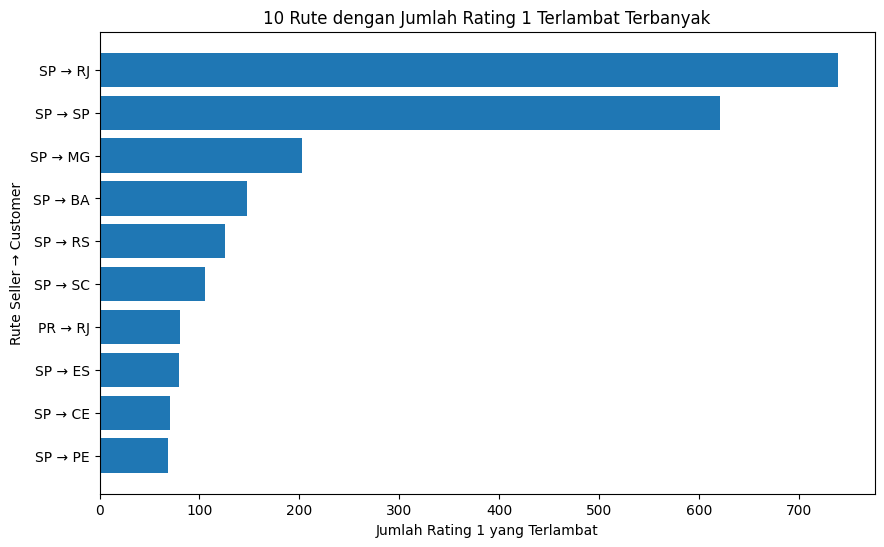

In [ ]:
#visualisasi rute kasus rating 1 terlambat paling banyak
top_jumlah = (analisis_rating1_rute.sort_values('jumlah_rating1', ascending=False).head(10).sort_values('jumlah_rating1'))

top_jumlah['rute'] = (top_jumlah.index.get_level_values('seller_state')+ ' → '+ top_jumlah.index.get_level_values('customer_state'))

plt.figure(figsize=(10, 6))
plt.barh(top_jumlah['rute'],top_jumlah['jumlah_rating1'])

plt.xlabel('Jumlah Rating 1 yang Terlambat')
plt.ylabel('Rute Seller → Customer')
plt.title('10 Rute dengan Jumlah Rating 1 Terlambat Terbanyak')
plt.show()

SP -> RJ merupakan rute dengan jumlah rating 1 terlambat terbanyak, disusul SP -> SP. ini menunjukkan bahwa kedua rute tersebut memiliki konsentrasi kasus rating 1 yang terlambat paling besar.

In [ ]:
# Rute dengan rata-rata keterlambatan paling parah
analisis_rating1_rute.sort_values(
    'ratarata_terlambat',
    ascending=False
).head(20)

jumlah_rating1  ratarata_terlambat
seller_state customer_state                                    
CE           AM                           1              104.00
MG           SE                           2               87.50
             PA                           4               57.75
RS           SP                           4               47.25
AM           AL                           1               38.00
GO           RJ                           2               34.00
SC           GO                           2               33.00
ES           RJ                           1               33.00
RJ           MA                           1               31.00
BA           PE                           1               31.00
MG           PI                           1               31.00
SP           AC                           1               31.00
BA           RJ                           1               31.00
SC           CE                           2               28.00
PR           CE                           9               27.67
PE           SP                           1               26.00
ES           PA                           1               25.00
DF           CE                           3               24.33
BA           AC                           1               24.00
CE           RJ                           1               23.00

In [ ]:
#Dari seluruh order pada suatu rute seller_state → customer_state, berapa persen yang rating 1 dan terlambat.
total_rute = (analysis_state_rating1.groupby(['seller_state', 'customer_state']).size().rename('total_order'))

analisis_rating1_rute_persentase = analisis_rating1_rute.join(total_rute)

analisis_rating1_rute_persentase['persentase_rating1_terlambat'] = (analisis_rating1_rute_persentase['jumlah_rating1'] / analisis_rating1_rute_persentase['total_order'] * 100).round(2)

analisis_rating1_rute_persentase = (analisis_rating1_rute_persentase[analisis_rating1_rute_persentase['total_order'] > 30].sort_values(
        'persentase_rating1_terlambat',ascending=False))

analisis_rating1_rute_persentase.head(20)

jumlah_rating1  ratarata_terlambat  total_order  \
seller_state customer_state                                                    
SP           AL                          30                9.33           44   
             PI                          28               12.57           44   
             SE                          22               12.18           36   
             MA                          51               11.73           86   
             CE                          71               17.82          123   
             MS                          30               11.80           55   
             RJ                         739               14.98         1360   
             RN                          18               12.72           34   
             PE                          69               13.46          138   
             PA                          49               13.55          102   
PR           RJ                          81               16.52          169   
MG           BA                          17               11.76           36   
SP           ES                          80               10.11          170   
             BA                         148               10.10          342   
RJ           SP                          59               11.00          142   
SP           PB                          16               10.94           39   
MG           RJ                          52               16.88          127   
SP           SC                         106                9.48          274   
             DF                          57                8.33          161   
SC           RJ                          24               17.62           68   

                             persentase_rating1_terlambat  
seller_state customer_state                                
SP           AL                                     68.18  
             PI                                     63.64  
             SE                                     61.11  
             MA                                     59.30  
             CE                                     57.72  
             MS                                     54.55  
             RJ                                     54.34  
             RN                                     52.94  
             PE                                     50.00  
             PA                                     48.04  
PR           RJ                                     47.93  
MG           BA                                     47.22  
SP           ES                                     47.06  
             BA                                     43.27  
RJ           SP                                     41.55  
SP           PB                                     41.03  
MG           RJ                                     40.94  
SP           SC                                     38.69  
             DF                                     35.40  
SC           RJ                                     35.29

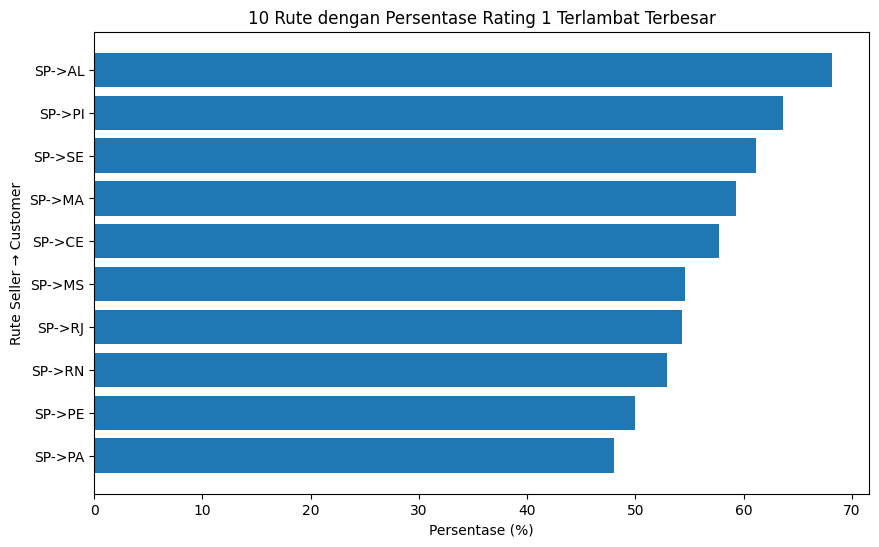

In [ ]:
#visualisasi rute dengan persentase terbesar
top_persen = (analisis_rating1_rute_persentase.sort_values('persentase_rating1_terlambat', ascending=False).head(10).sort_values('persentase_rating1_terlambat'))

top_persen['rute'] = (top_persen.index.get_level_values('seller_state')+ '->' + top_persen.index.get_level_values('customer_state'))

plt.figure(figsize=(10, 6))
plt.barh(top_persen['rute'],top_persen['persentase_rating1_terlambat'])
plt.xlabel('Persentase (%)')
plt.ylabel('Rute Seller → Customer')
plt.title('10 Rute dengan Persentase Rating 1 Terlambat Terbesar')

plt.show()


rute seller SP muncul berulang kali sebagai titik asal seller dalam rute dengan proporsi rating 1 terlambat yang tinggi, sehingga rute yang berasal dari SP layak mendapat perhatian lebih lanjut untuk mengevaluasi faktor logistik yang mungkin berkontribusi terhadap keterlambatan.

In [ ]:
#Kalau masalah ini dibiarkan, seberapa besar nilai transaksi yang terdampak
#berapa nilai transaksi yang terdampak

#buat salinan dataframe analysis state rating 1
analysis_rating1_keuangan = analysis_state_rating1.copy()

#siapkan price dan freight
order_nilai = (order_items.groupby('order_id').agg(total_price=('price', 'sum'), total_freight=('freight_value', 'sum')).reset_index())

#gabungkan dengan tabel rating 1
analysis_rating1_keuangan = analysis_rating1_keuangan.merge(order_nilai, on='order_id', how='left')

#ambil hanya rating 1 dengan status terlambat
analysis_rating1_keuangan = analysis_rating1_keuangan[analysis_rating1_keuangan['terlambat(hari)'] > 0]

#hitung gmv per rute
gmv_rute = (analysis_rating1_keuangan.groupby(['seller_state', 'customer_state'])
          .agg(jumlah_order=('order_id', 'count'), total_gmv=('total_price', 'sum'))
          .round(2).sort_values('total_gmv', ascending=False))

gmv_rute.head()

jumlah_order  total_gmv
seller_state customer_state                         
SP           RJ                       739  100673.60
             SP                       621   99915.95
             MG                       203   31098.40
             BA                       148   26026.44
             RS                       126   17351.43

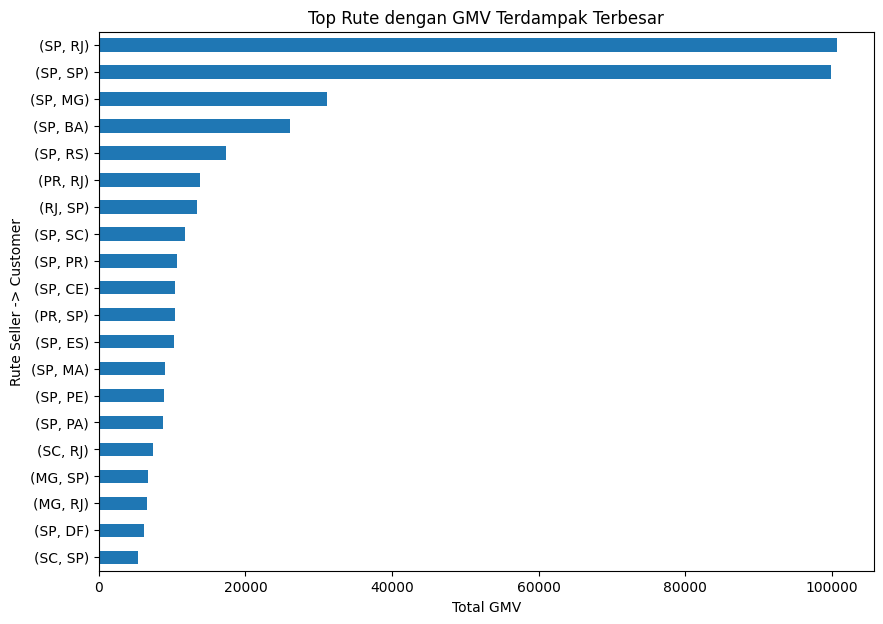

In [ ]:
#"Dari order bermasalah tersebut, rute mana yang membawa nilai transaksi paling besar?"

gmv_rute['total_gmv'].head(20).sort_values().plot(kind='barh', figsize=(10,7))
plt.xlabel('Total GMV')
plt.ylabel('Rute Seller -> Customer')
plt.title('Top Rute dengan GMV Terdampak Terbesar')
plt.show()

SP -> RJ dan SP -> SP bukan hanya memiliki jumlah rating 1 terlambat yang tinggi, tetapi juga memiliki nilai transaksi (price) yang terdampak besar, hal ini menjadikan rute-rute tersebut relevan untuk di prioritaskan dalam evaluasi logistik.

In [ ]:
#berapa beban ongkir pada order bermasalah
ongkir_rute = (analysis_rating1_keuangan.groupby(['seller_state', 'customer_state'])
  .agg(jumlah_order=('order_id', 'count'), total_ongkir=('total_freight', 'sum'))
  .round(2).sort_values('total_ongkir', ascending=False))
ongkir_rute.head(20)

jumlah_order  total_ongkir
seller_state customer_state                            
SP           RJ                       739      17873.87
             SP                       621      10907.45
             MG                       203       4997.24
             BA                       148       4132.22
             RS                       126       2743.49
             SC                       106       2523.18
             CE                        71       2386.73
             PE                        69       2243.06
             MA                        51       2129.75
PR           RJ                        81       1870.64
SP           PR                        63       1728.01
             ES                        80       1707.04
             PA                        49       1664.57
MG           RJ                        52       1520.28
             SP                        31       1460.39
SP           DF                        57       1377.22
PR           SP                        58       1243.45
SP           GO                        52       1208.34
             PI                        28       1208.14
RJ           SP                        59       1090.24

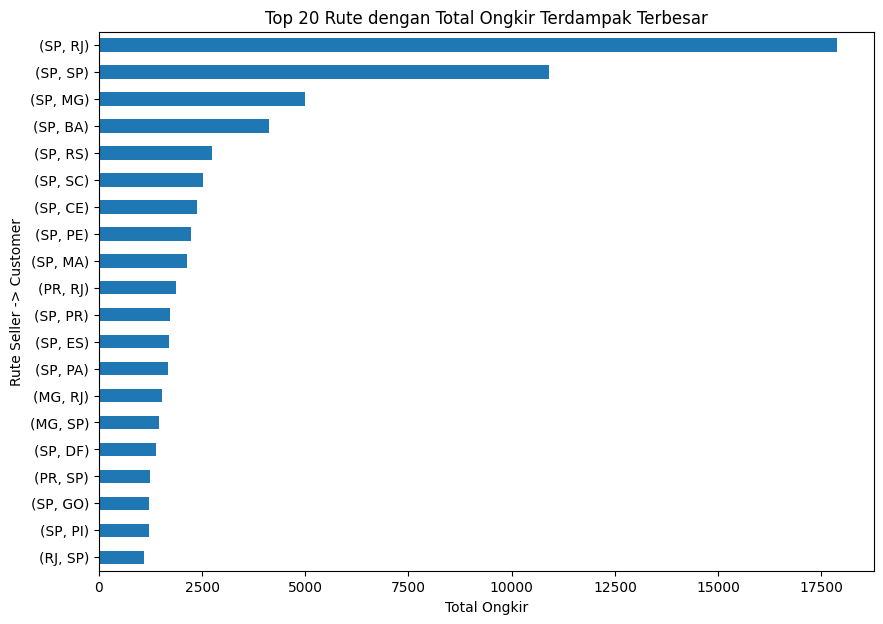

In [ ]:
ongkir_rute['total_ongkir'].head(20).sort_values().plot(kind='barh', figsize=(10,7))
plt.xlabel('Total Ongkir')
plt.ylabel('Rute Seller -> Customer')
plt.title('Top 20 Rute dengan Total Ongkir Terdampak Terbesar')
plt.show()

pun demikian pada total ongkir terdampak paling besar pada rute seller SP -> RJ yang secara konsisten menempati urutan tertinggi dalam hal jumlah pesanan rating 1 yang terlambat, nilai GMV (price) yang terdampak, dan total biaya pengiriman (ongkir).